# Literature Review - Trend Analysis

This notebook analyzes publication trends, modeling methods, spatial scales, and compound hazard types in the literature review dataset.

**Notes for reuse**

- The processed datasets supporting the findings of this systematic review are available from the authors upon reasonable request.
- Optional exports are disabled by default to avoid writing files during exploratory reruns.

## 1. Setup

Import packages, set display options, and define constants used throughout the workflow.


In [1]:
from __future__ import annotations

import os
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

EXPORT_OUTPUTS = True
RANDOM_SEED = 42

plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 2. Configuration

Update these paths if your literature workbook is stored somewhere else. Environment variables take precedence, which makes the notebook easier to rerun across local machines.

- `LITERATURE_FILE`: full path to the literature review workbook.
- `TREND_OUTPUT_DIR`: output directory for optional generated tables and figures.


In [2]:
PROJECT_ROOT = Path.cwd()

LITERATURE_FILE = Path(
    os.getenv("LITERATURE_FILE", PROJECT_ROOT / "archive" / "literature_review_final.xlsx")
).expanduser().resolve()

OUTPUT_DIR = Path(os.getenv("TREND_OUTPUT_DIR", PROJECT_ROOT / "output" / "trend_analysis")).resolve()

# print(f"Project root: {PROJECT_ROOT}")
# print(f"Literature workbook: {LITERATURE_FILE}")
# print(f"Output directory: {OUTPUT_DIR}")


## 3. Helper Functions

The helpers below keep data cleaning, aggregation, and plotting behavior explicit and reusable.


In [64]:
from __future__ import annotations


METHOD_CATEGORY_ORDER = [
    "Physics-based methods",
    "Data-driven methods",
    "Hybrid methods",
]

METHOD_CATEGORY_MAP = {
    "Physics-based": "Physics-based methods",
    "Data-driven": "Data-driven methods",
    "Hybrid": "Hybrid methods",
    "Physics-based methods": "Physics-based methods",
    "Data-driven methods": "Data-driven methods",
    "Hybrid methods": "Hybrid methods",
}

METHOD_CATEGORY_COLORS = {
    "Physics-based methods": "#498ECA",
    "Data-driven methods": "#22315F",
    "Hybrid methods": "#E1A637",
}

SCALE_ORDER = ["Global", "Regional", "City", "Community"]
SCALE_LABELS = {
    "Global": "Global-scale",
    "Regional": "Regional-scale",
    "City": "City-scale",
    "Community": "Community-scale",
}

plt.rcParams.update({
    'font.size': 24,          # Base font size
    'axes.titlesize': 24,     # Title font size
    'axes.labelsize': 24,     # X and Y label font size
    'xtick.labelsize': 24,    # X tick labels
    'ytick.labelsize': 24,    # Y tick labels
    'legend.fontsize': 24,    # Legend text
    'legend.title_fontsize': 24 # Legend title
})

def require_file(path: Path, description: str) -> Path:
    """Return a path if it exists; otherwise raise a clear, actionable error."""
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {description}: {path}\n"
            "Update the configuration cell or set the corresponding environment variable."
        )
    return path


def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize known column-name variants across workbook versions."""
    rename_map = {
        "Method_Category": "Method_category",
        "method_category": "Method_category",
        "Publication year": "Publication Year",
    }
    return df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns})


def load_literature_workbook(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load the main coded literature sheet and optional compound hazard summaries."""
    workbook = require_file(path, "literature review workbook")
    sheets = pd.ExcelFile(workbook).sheet_names

    records = normalize_column_names(pd.read_excel(workbook, sheet_name="Step 3"))

    if "Compound_type" in sheets:
        hazard_type = pd.read_excel(workbook, sheet_name="Compound_type")
    else:
        hazard_type = pd.DataFrame()

    if "Compound_type_sum" in sheets:
        hazard_type_sum = pd.read_excel(workbook, sheet_name="Compound_type_sum")
    else:
        hazard_type_sum = pd.DataFrame()

    return records, hazard_type, hazard_type_sum


def clean_literature_records(df: pd.DataFrame) -> pd.DataFrame:
    """Clean key columns and standardize method category labels."""
    out = normalize_column_names(df).copy()
    required = ["Publication Year", "Scale", "Method_category", "Method"]
    missing = [col for col in required if col not in out.columns]
    if missing:
        raise KeyError(f"Missing required columns in literature records: {missing}")

    out["Publication Year"] = pd.to_numeric(out["Publication Year"], errors="coerce").astype("Int64")
    for col in ["Scale", "Method_category", "Method", "Specific_methods", "Hazard_type"]:
        if col in out.columns:
            out[col] = out[col].astype("string").str.strip()

    out["Method_category"] = out["Method_category"].map(METHOD_CATEGORY_MAP).fillna(out["Method_category"])
    out = out.dropna(subset=["Publication Year"]).copy()
    return out


def split_pipe_values(value) -> list[str]:
    """Split pipe-delimited workbook cells into stripped unique values."""
    if pd.isna(value):
        return []
    parts = [part.strip() for part in str(value).split("|") if part.strip()]
    return sorted(set(parts))


def explode_pipe_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """Explode a pipe-delimited column while preserving all other record fields."""
    out = df.copy()
    out[column] = out[column].apply(split_pipe_values)
    out = out.explode(column)
    out = out.dropna(subset=[column])
    out = out[out[column].astype(str).str.strip() != ""].copy()
    out[column] = out[column].astype(str).str.strip()
    return out


def ordered_crosstab(df: pd.DataFrame, index: str, columns: str, column_order: list[str]) -> pd.DataFrame:
    """Build a count table with stable column ordering."""
    table = pd.crosstab(df[index], df[columns])
    ordered_columns = [col for col in column_order if col in table.columns]
    return table.reindex(columns=ordered_columns)


def method_pair_table(df: pd.DataFrame, method_col: str = "Method") -> pd.DataFrame:
    """Count undirected method co-occurrences within each publication."""
    pair_counter = Counter()
    for methods in df[method_col].dropna():
        method_list = split_pipe_values(methods)
        for pair in combinations(method_list, 2):
            pair_counter[pair] += 1

    return (
        pd.DataFrame(
            [(source, target, weight) for (source, target), weight in pair_counter.items()],
            columns=["Source", "Target", "Weight"],
        )
        .sort_values("Weight", ascending=False)
        .reset_index(drop=True)
    )


def method_count_table(df: pd.DataFrame, method_col: str = "Method") -> pd.DataFrame:
    """Count method mentions after splitting multi-method cells."""
    exploded = explode_pipe_column(df, method_col)
    return (
        exploded[method_col]
        .value_counts()
        .rename_axis("Method")
        .reset_index(name="Frequency")
    )


def build_method_graph(edge_df: pd.DataFrame) -> nx.Graph:
    """Build a weighted method co-occurrence graph."""
    graph = nx.Graph()
    for _, row in edge_df.iterrows():
        graph.add_edge(row["Source"], row["Target"], weight=float(row["Weight"]))
    return graph


def plot_stacked_method_categories(yearly_category_counts: pd.DataFrame):
    """Plot annual publications by method category."""
    colors = [METHOD_CATEGORY_COLORS[col] for col in yearly_category_counts.columns]
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    yearly_category_counts.plot(kind="bar", stacked=True, color=colors, ax=ax)
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Number of publications")
    ax.legend(frameon=True, loc="upper left")
    ax.grid(True, axis="y", alpha=0.25)
    plt.xticks(rotation=0)
    plt.tight_layout()
    return fig, ax


def plot_compound_hazard_types(hazard_summary: pd.DataFrame):
    """Plot compound hazard type frequencies from the summary sheet."""
    if hazard_summary.empty:
        print("Compound_type_sum sheet is unavailable; skipping hazard type plot.")
        return None, None

    df_plot = hazard_summary[["Compound hazard type", "Frequency"]].dropna().copy()
    other_row = df_plot[df_plot["Compound hazard type"] == "Others"]
    df_plot = df_plot[df_plot["Compound hazard type"] != "Others"].sort_values("Frequency", ascending=True)
    df_plot = pd.concat([other_row, df_plot], ignore_index=True)

    fig, ax = plt.subplots(figsize=(12, 7), dpi=600)
    ax.barh(df_plot["Compound hazard type"], df_plot["Frequency"], color="#BDBDBD")
    ax.set_xlabel("Number of publications")
    ax.set_xlim(0, df_plot["Frequency"].max() * 1.35)
    ax.grid(True, axis="x", alpha=0.25)
    for idx, value in enumerate(df_plot["Frequency"]):
        ax.text(value + 1, idx, str(int(value)), va="center")
    plt.tight_layout()
    return fig, ax


def make_scale_category_sankey(df: pd.DataFrame) -> go.Figure:
    """Create a Sankey diagram for Scale -> Method category."""
    links = df.groupby(["Scale_Label", "Method_category"]).size().reset_index(name="value")
    links.columns = ["source", "target", "value"]

    scale_nodes = [SCALE_LABELS[scale] for scale in SCALE_ORDER if SCALE_LABELS[scale] in df["Scale_Label"].unique()]
    category_nodes = [cat for cat in METHOD_CATEGORY_ORDER if cat in df["Method_category"].unique()]
    all_nodes = scale_nodes + category_nodes

    mapping = {name: idx for idx, name in enumerate(all_nodes)}
    links["source_id"] = links["source"].map(mapping)
    links["target_id"] = links["target"].map(mapping)

    node_colors = [
        "#747474" if node in scale_nodes else METHOD_CATEGORY_COLORS.get(node, "#CCCCCC")
        for node in all_nodes
    ]

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="fixed",
                textfont=dict(size=24, color="black", family="Arial"),
                node=dict(
                    pad=35,
                    thickness=22,
                    line=dict(color="black", width=0.5),
                    label=all_nodes,
                    color=node_colors,
                ),
                link=dict(
                    source=links["source_id"],
                    target=links["target_id"],
                    value=links["value"],
                    color="rgba(180,180,180,0.4)",
                ),
            )
        ]
    )
    
    fig.update_layout(width=1000, height=700, margin=dict(l=20, r=20, t=40, b=20))
    return fig


def make_scale_category_method_sankey(df: pd.DataFrame) -> go.Figure:
    """Create a Sankey diagram for Scale -> Method category -> Method."""
    exploded = explode_pipe_column(df, "Method")
    flow_1 = exploded.groupby(["Scale_Label", "Method_category"]).size().reset_index(name="value")
    flow_1.columns = ["source", "target", "value"]
    flow_2 = exploded.groupby(["Method_category", "Method"]).size().reset_index(name="value")
    flow_2.columns = ["source", "target", "value"]
    links = pd.concat([flow_1, flow_2], axis=0, ignore_index=True)

    scale_nodes = [SCALE_LABELS[scale] for scale in SCALE_ORDER if SCALE_LABELS[scale] in exploded["Scale_Label"].unique()]
    category_nodes = [cat for cat in METHOD_CATEGORY_ORDER if cat in exploded["Method_category"].unique()]
    method_nodes = sorted(exploded["Method"].dropna().unique())
    all_nodes = scale_nodes + category_nodes + method_nodes

    mapping = {name: idx for idx, name in enumerate(all_nodes)}
    links["source_id"] = links["source"].map(mapping)
    links["target_id"] = links["target"].map(mapping)
    links = links.dropna(subset=["source_id", "target_id"]).copy()

    node_colors = []
    for node in all_nodes:
        if node in scale_nodes:
            node_colors.append("#747474")
        elif node in category_nodes:
            node_colors.append(METHOD_CATEGORY_COLORS.get(node, "#CCCCCC"))
        else:
            node_colors.append("#9E9E9E")

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="fixed",
                textfont=dict(size=14, color="black", family="Arial"),
                node=dict(
                    pad=18,
                    thickness=22,
                    line=dict(color="black", width=0.5),
                    # label=all_nodes,
                    color=node_colors,
                ),
                link=dict(
                    source=links["source_id"].astype(int),
                    target=links["target_id"].astype(int),
                    value=links["value"],
                    color="rgba(180,180,180,0.35)",
                ),
            )
        ]
    )
    fig.update_layout(width=1200, height=900, margin=dict(l=120, r=20, t=40, b=20))
    return fig


def build_chord_matrix(edge_df: pd.DataFrame, method_counts: pd.DataFrame) -> pd.DataFrame:
    """Build a symmetric adjacency matrix for optional chord diagrams."""
    methods = sorted(method_counts["Method"].unique())
    matrix = pd.DataFrame(0, index=methods, columns=methods, dtype=int)
    for _, row in edge_df.iterrows():
        matrix.loc[row["Source"], row["Target"]] = int(row["Weight"])
        matrix.loc[row["Target"], row["Source"]] = int(row["Weight"])
    return matrix


def plot_optional_chord(matrix: pd.DataFrame):
    """Create a chord diagram when pycirclize is installed."""
    try:
        from pycirclize import Circos
    except Exception as exc:
        print(f"pycirclize is unavailable; skipping chord diagram: {exc}")
        return None

    circos = Circos.chord_diagram(
        matrix,
        space=3,
        r_lim=(90, 100),
        cmap="tab20",
        label_kws=dict(r=110, size=8, orientation="vertical"),
    )
    return circos.plotfig(dpi=300)


## 4. Load and Validate Data

Load the coded literature records and compound hazard type summaries from the workbook.


In [4]:
raw_df, hazard_type, hazard_type_sum = load_literature_workbook(LITERATURE_FILE)
literature_df = clean_literature_records(raw_df)

literature_df["Scale_Label"] = literature_df["Scale"].map(SCALE_LABELS).fillna(literature_df["Scale"])

print(f"Literature records: {literature_df.shape[0]:,}")
print(f"Columns: {literature_df.shape[1]:,}")
literature_df[["Paper_ID", "Publication Year", "Scale", "Method_category", "Method", "Hazard_type"]].head()


Literature records: 171
Columns: 90


,Paper_ID,Publication Year,Scale,Method_category,Method,Hazard_type
0,1,2025,Regional,Data-driven methods,Event coincidence analysis,flood-heatwave
1,3,2025,Regional,Data-driven methods,Multivariate dependence modeling,extreme temperature-extreme precipitation | ex...
2,4,2025,Regional,Data-driven methods,Multivariate dependence modeling,heatwave-extreme precipitation | drought-heatwave
3,6,2025,Regional,Data-driven methods,Multivariate dependence modeling,compound flood
4,7,2025,Regional,Data-driven methods,Multivariate dependence modeling,drought-extreme temperature


In [5]:
KEY_COLUMNS = ["Publication Year", "Scale", "Method_category", "Method", "Hazard_type"]

for col in KEY_COLUMNS:
    if col in literature_df.columns:
        values = sorted(literature_df[col].dropna().astype(str).str.strip().unique().tolist())
        print(f"\n--- {col} ---")
        print(f"Unique values: {len(values)}")
        print(values[:50])



--- Publication Year ---
Unique values: 11
['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

--- Scale ---
Unique values: 4
['City', 'Community', 'Global', 'Regional']

--- Method_category ---
Unique values: 3
['Data-driven methods', 'Hybrid methods', 'Physics-based methods']

--- Method ---
Unique values: 40
['Atmospheric model', 'Atmospheric model | Hydrodynamic model | Hydrological model', 'Atmospheric model | Hydrodynamic model | Urban canopy model', 'Atmospheric model | Hydrological model | Hydrodynamic model', 'Ballistic trajectory model | Ignition model | Fire spread model', 'Coupled meteorology-atmospheric chemistry model', 'Debris flow model', 'Deep learning', 'Earth system model', 'Earthquake model | Hydraulic model', 'Earthquake model | Ignition model | Hydraulic model | Debris flow model', 'Event coincidence analysis', 'Hydraulic model | Surrogate model', 'Hydrodynamic model', 'Hydrodynamic model | Multivariate dependence modeling', 

## 5. Publication Trends

Summarize the number of publications per year and the distribution of method categories over time.


In [6]:
yearly_counts = (
    literature_df["Publication Year"]
    .value_counts()
    .sort_index()
    .rename_axis("Publication Year")
    .reset_index(name="Publication_Count")
)

yearly_counts


,Publication Year,Publication_Count
0,2015,1
1,2016,3
2,2017,4
3,2018,8
4,2019,6
5,2020,10
6,2021,18
7,2022,21
8,2023,24
9,2024,32


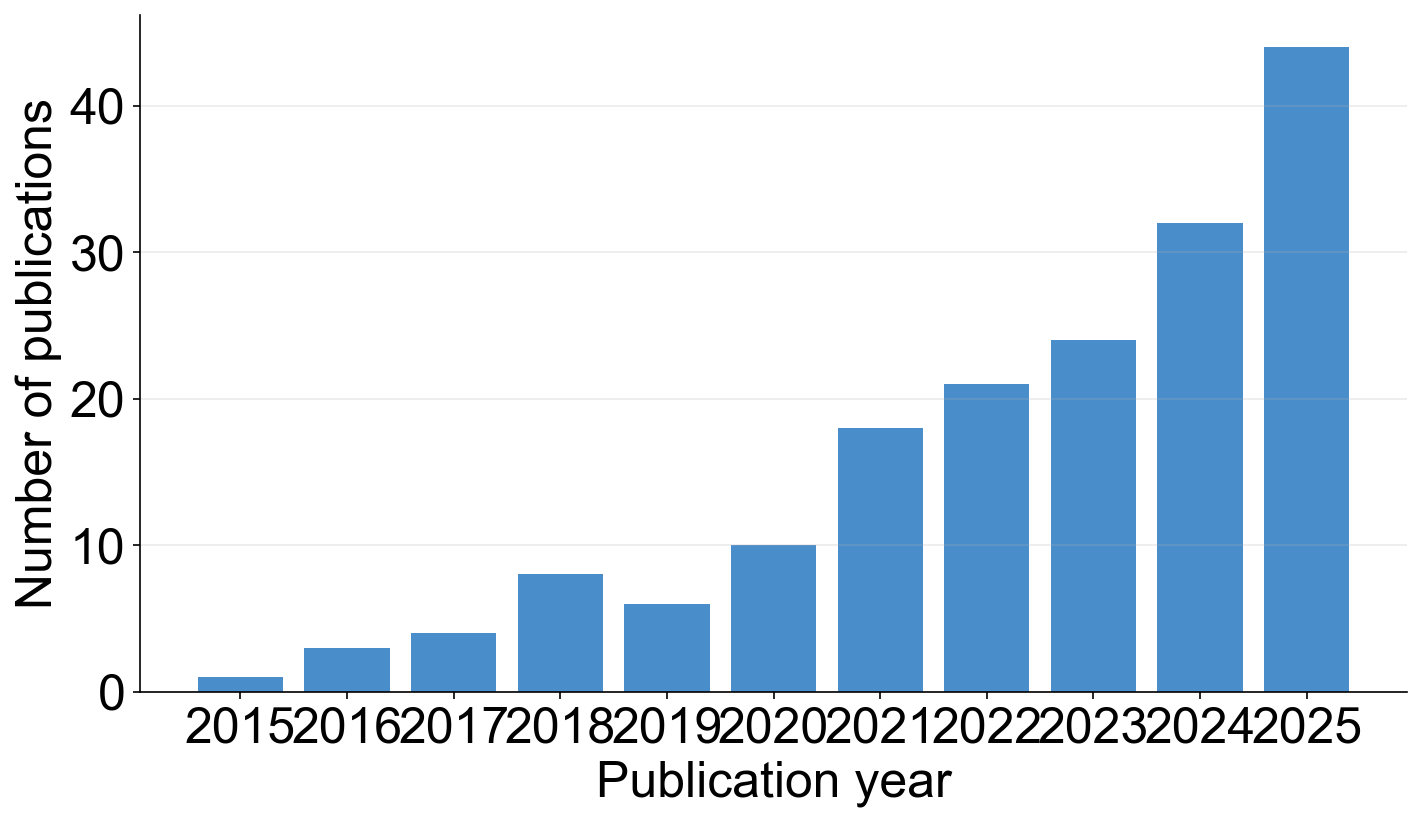

In [7]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.bar(yearly_counts["Publication Year"].astype(str), yearly_counts["Publication_Count"], color="#498ECA")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of publications")
ax.grid(True, axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
yearly_category_counts = ordered_crosstab(
    literature_df,
    index="Publication Year",
    columns="Method_category",
    column_order=METHOD_CATEGORY_ORDER,
)

yearly_category_counts


Method_category,Physics-based methods,Data-driven methods,Hybrid methods
Publication Year,,,
2015,0,1,0
2016,1,2,0
2017,1,3,0
2018,2,5,1
2019,1,4,1
2020,3,5,2
2021,5,12,1
2022,5,14,2
2023,10,14,0


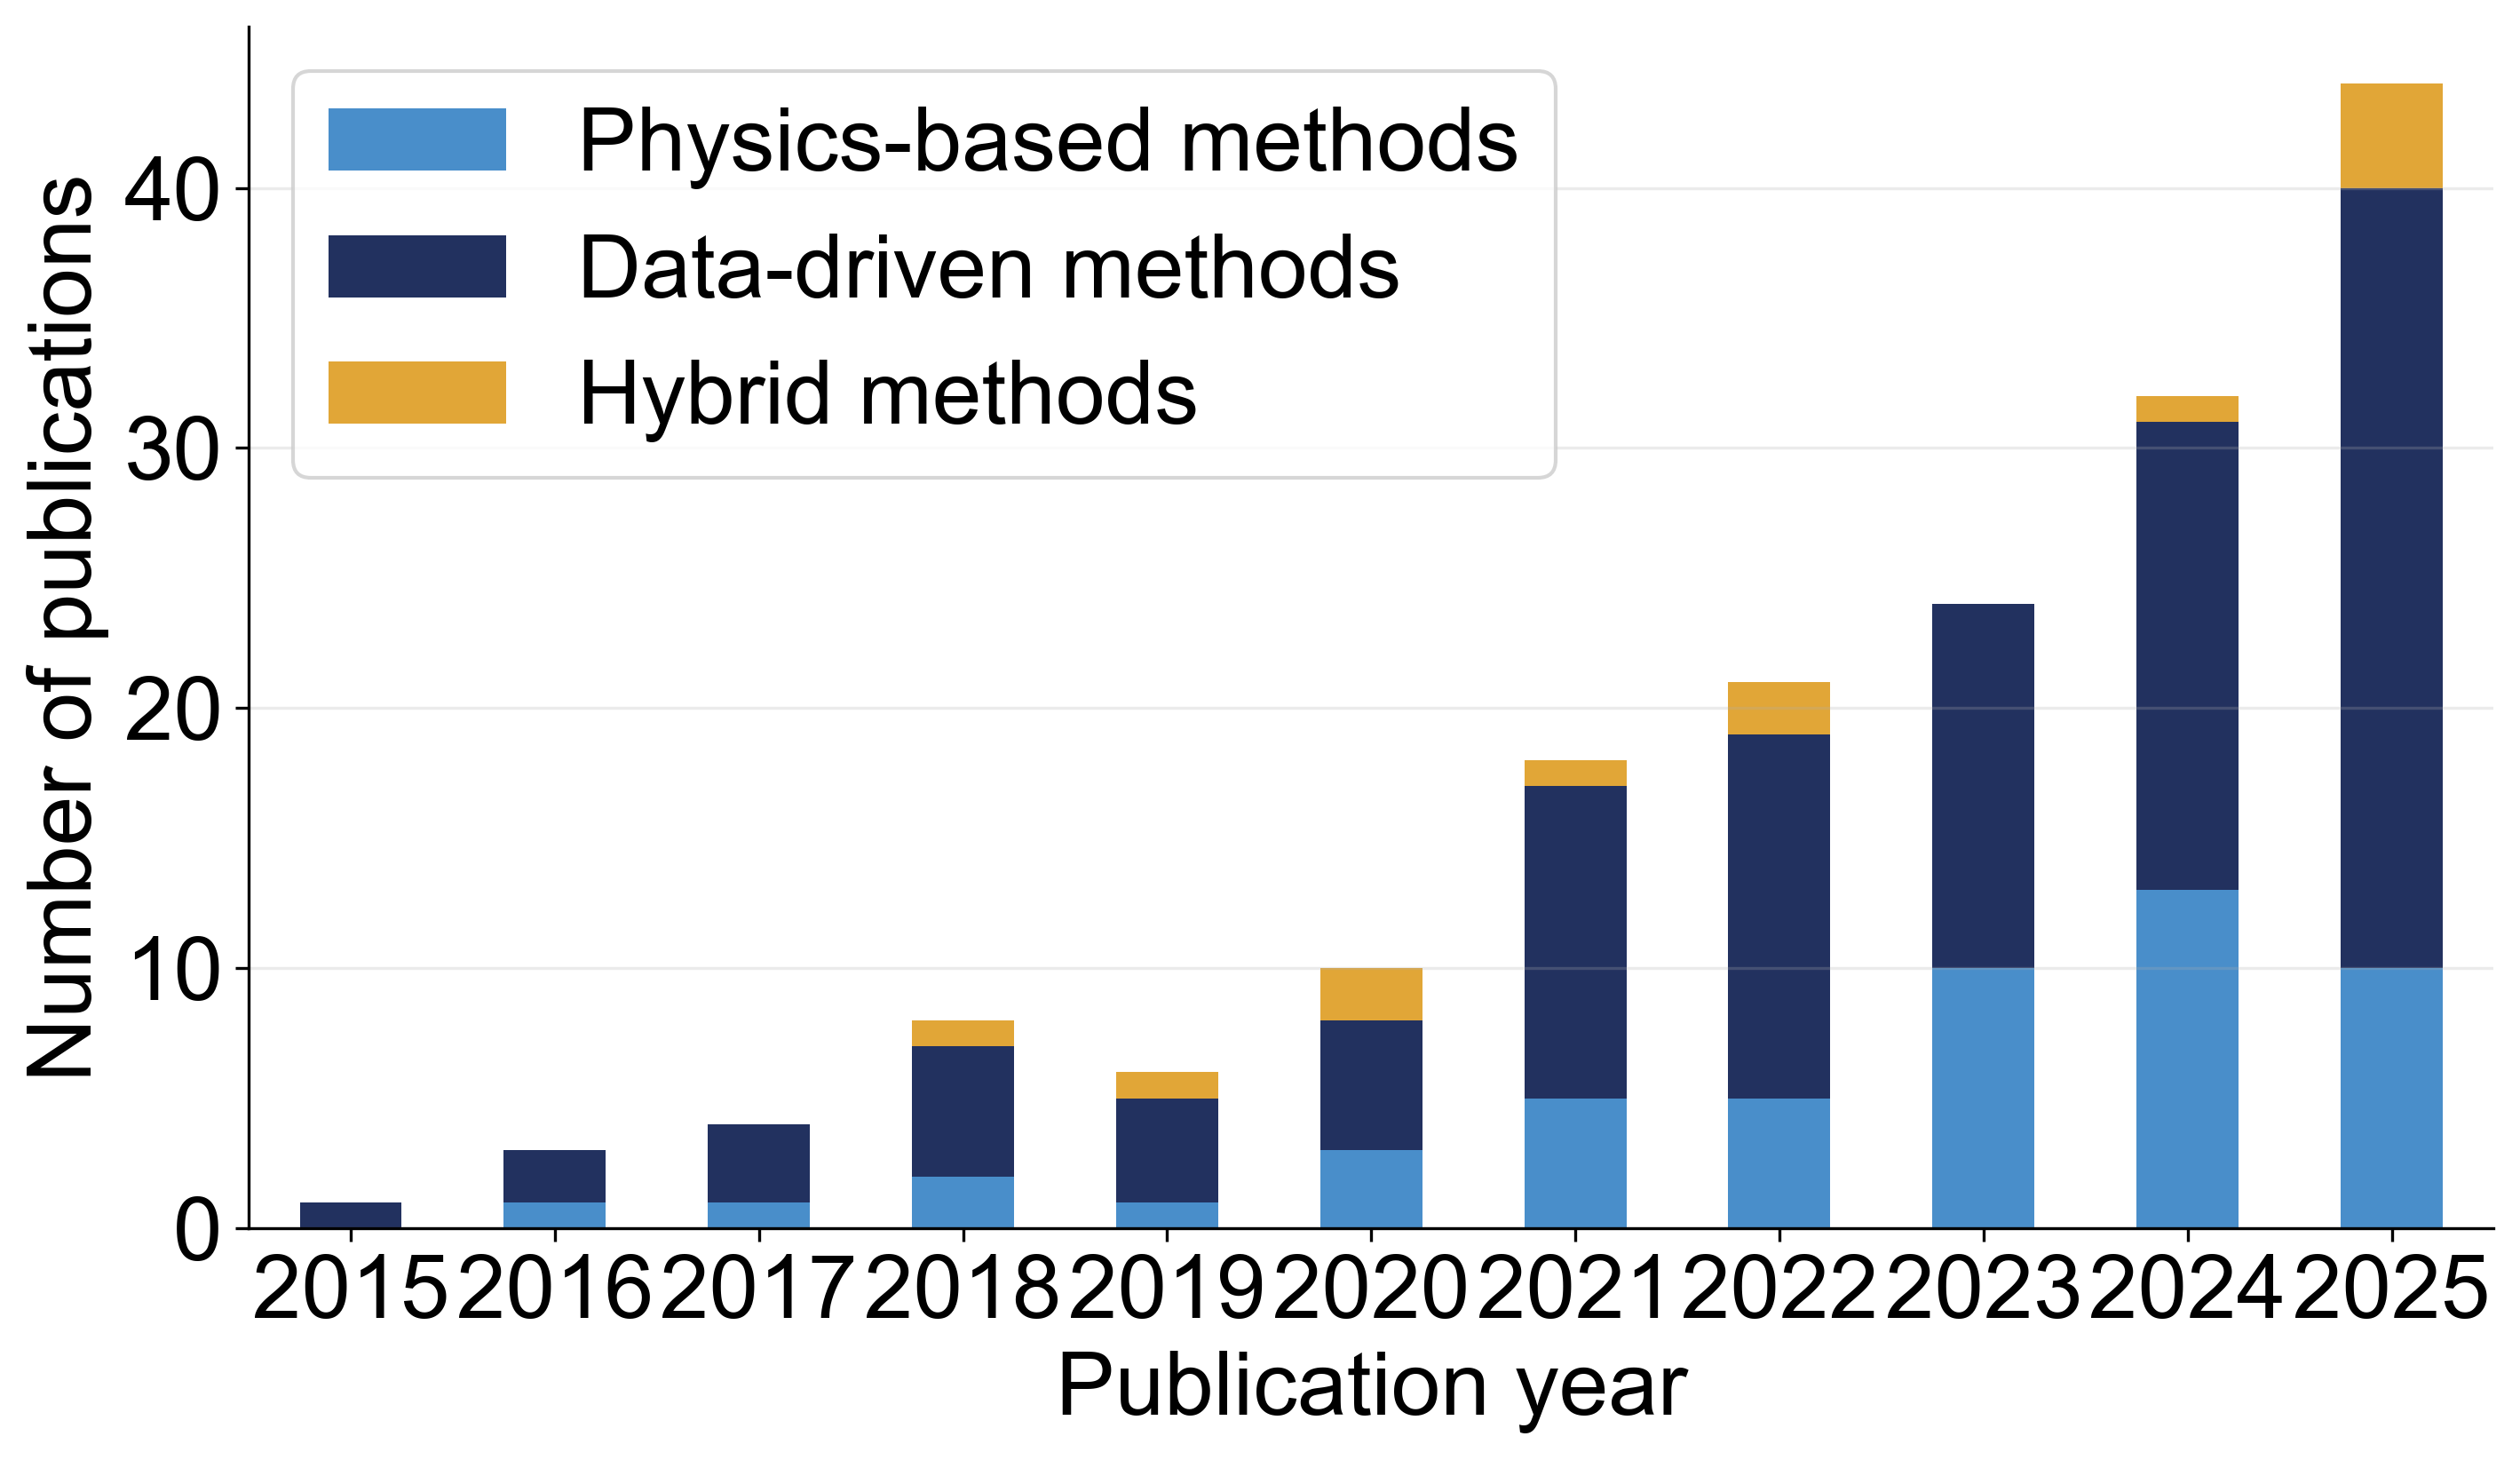

In [9]:
fig, ax = plot_stacked_method_categories(yearly_category_counts)

if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "publications_by_method_category.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


## 6. Spatial Scale and Method Categories

Compare method category composition across spatial scales.


In [10]:
scale_counts = (
    literature_df["Scale"]
    .value_counts()
    .reindex([scale for scale in SCALE_ORDER if scale in literature_df["Scale"].unique()])
    .rename_axis("Scale")
    .reset_index(name="Publication_Count")
)

scale_counts


,Scale,Publication_Count
0,Global,19
1,Regional,124
2,City,20
3,Community,8


In [11]:
scale_category_counts = ordered_crosstab(
    literature_df,
    index="Scale",
    columns="Method_category",
    column_order=METHOD_CATEGORY_ORDER,
).reindex([scale for scale in SCALE_ORDER if scale in literature_df["Scale"].unique()])

scale_category_share = scale_category_counts.div(scale_category_counts.sum(axis=1), axis=0)
scale_category_share


Method_category,Physics-based methods,Data-driven methods,Hybrid methods
Scale,,,
Global,0.105263,0.894737,0.000000
Regional,0.258065,0.685484,0.056452
City,0.550000,0.250000,0.200000
Community,0.750000,0.125000,0.125000


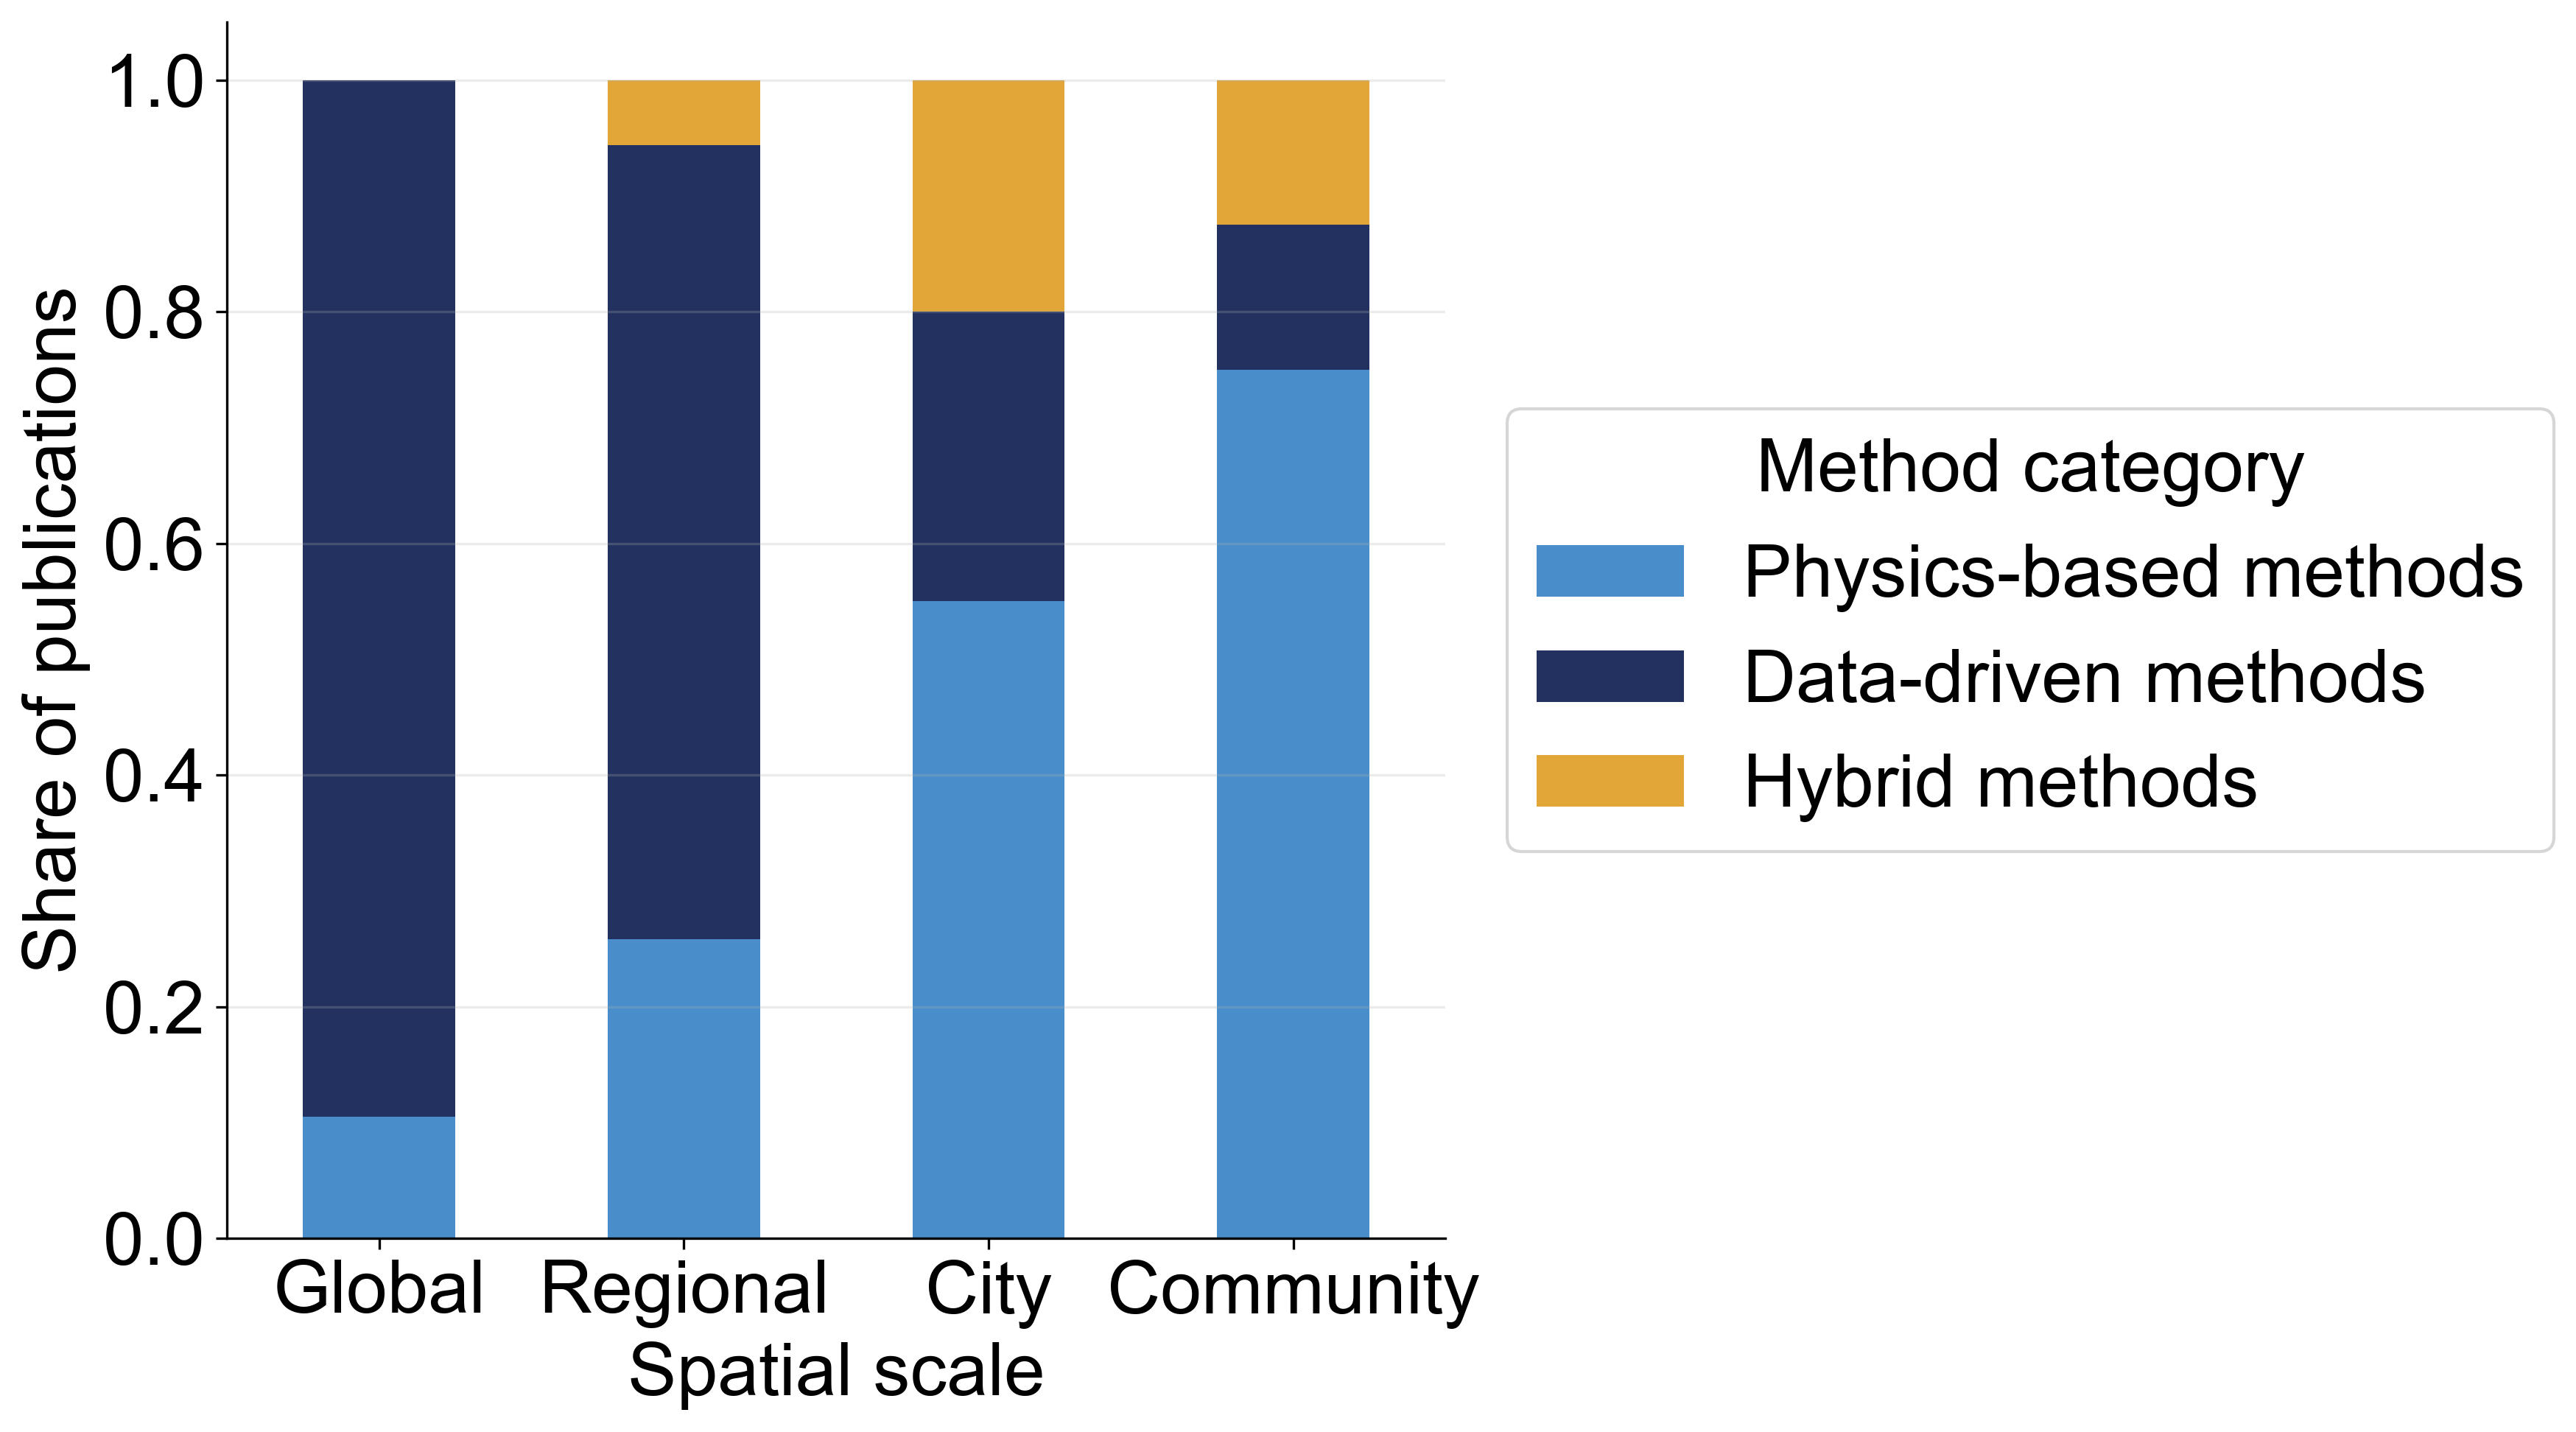

In [12]:
fig, ax = plt.subplots(figsize=(15, 7), dpi=300)

colors = [METHOD_CATEGORY_COLORS[col] for col in scale_category_share.columns]
scale_category_share.plot(kind="bar", stacked=True, color=colors, ax=ax)

ax.set_xlabel("Spatial scale")
ax.set_ylabel("Share of publications")

# Put legend outside on the right
ax.legend(
    frameon=True,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Method category"
)

ax.grid(True, axis="y", alpha=0.25)
plt.xticks(rotation=0)

# Leave room for outside legend
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

## 7. Compound Hazard Types

Summarize the compound hazard type frequencies coded in the workbook.


In [24]:
hazard_type_sum_clean = hazard_type_sum[["Compound hazard type", "Frequency"]].dropna().copy()
hazard_type_sum_clean["Frequency"] = pd.to_numeric(hazard_type_sum_clean["Frequency"], errors="coerce")
hazard_type_sum_clean = hazard_type_sum_clean.dropna(subset=["Frequency"]).sort_values("Frequency", ascending=False)

hazard_type_sum_clean


,Compound hazard type,Frequency
0,Compound flooding,56
6,Others,41
1,Extreme temperature-Extreme precipitation,36
2,Extreme temperature-Drought,23
3,Flood-Mass movement,6
4,Extreme precipitation-Strong wind,5
5,Earthquake-Mass movement,4


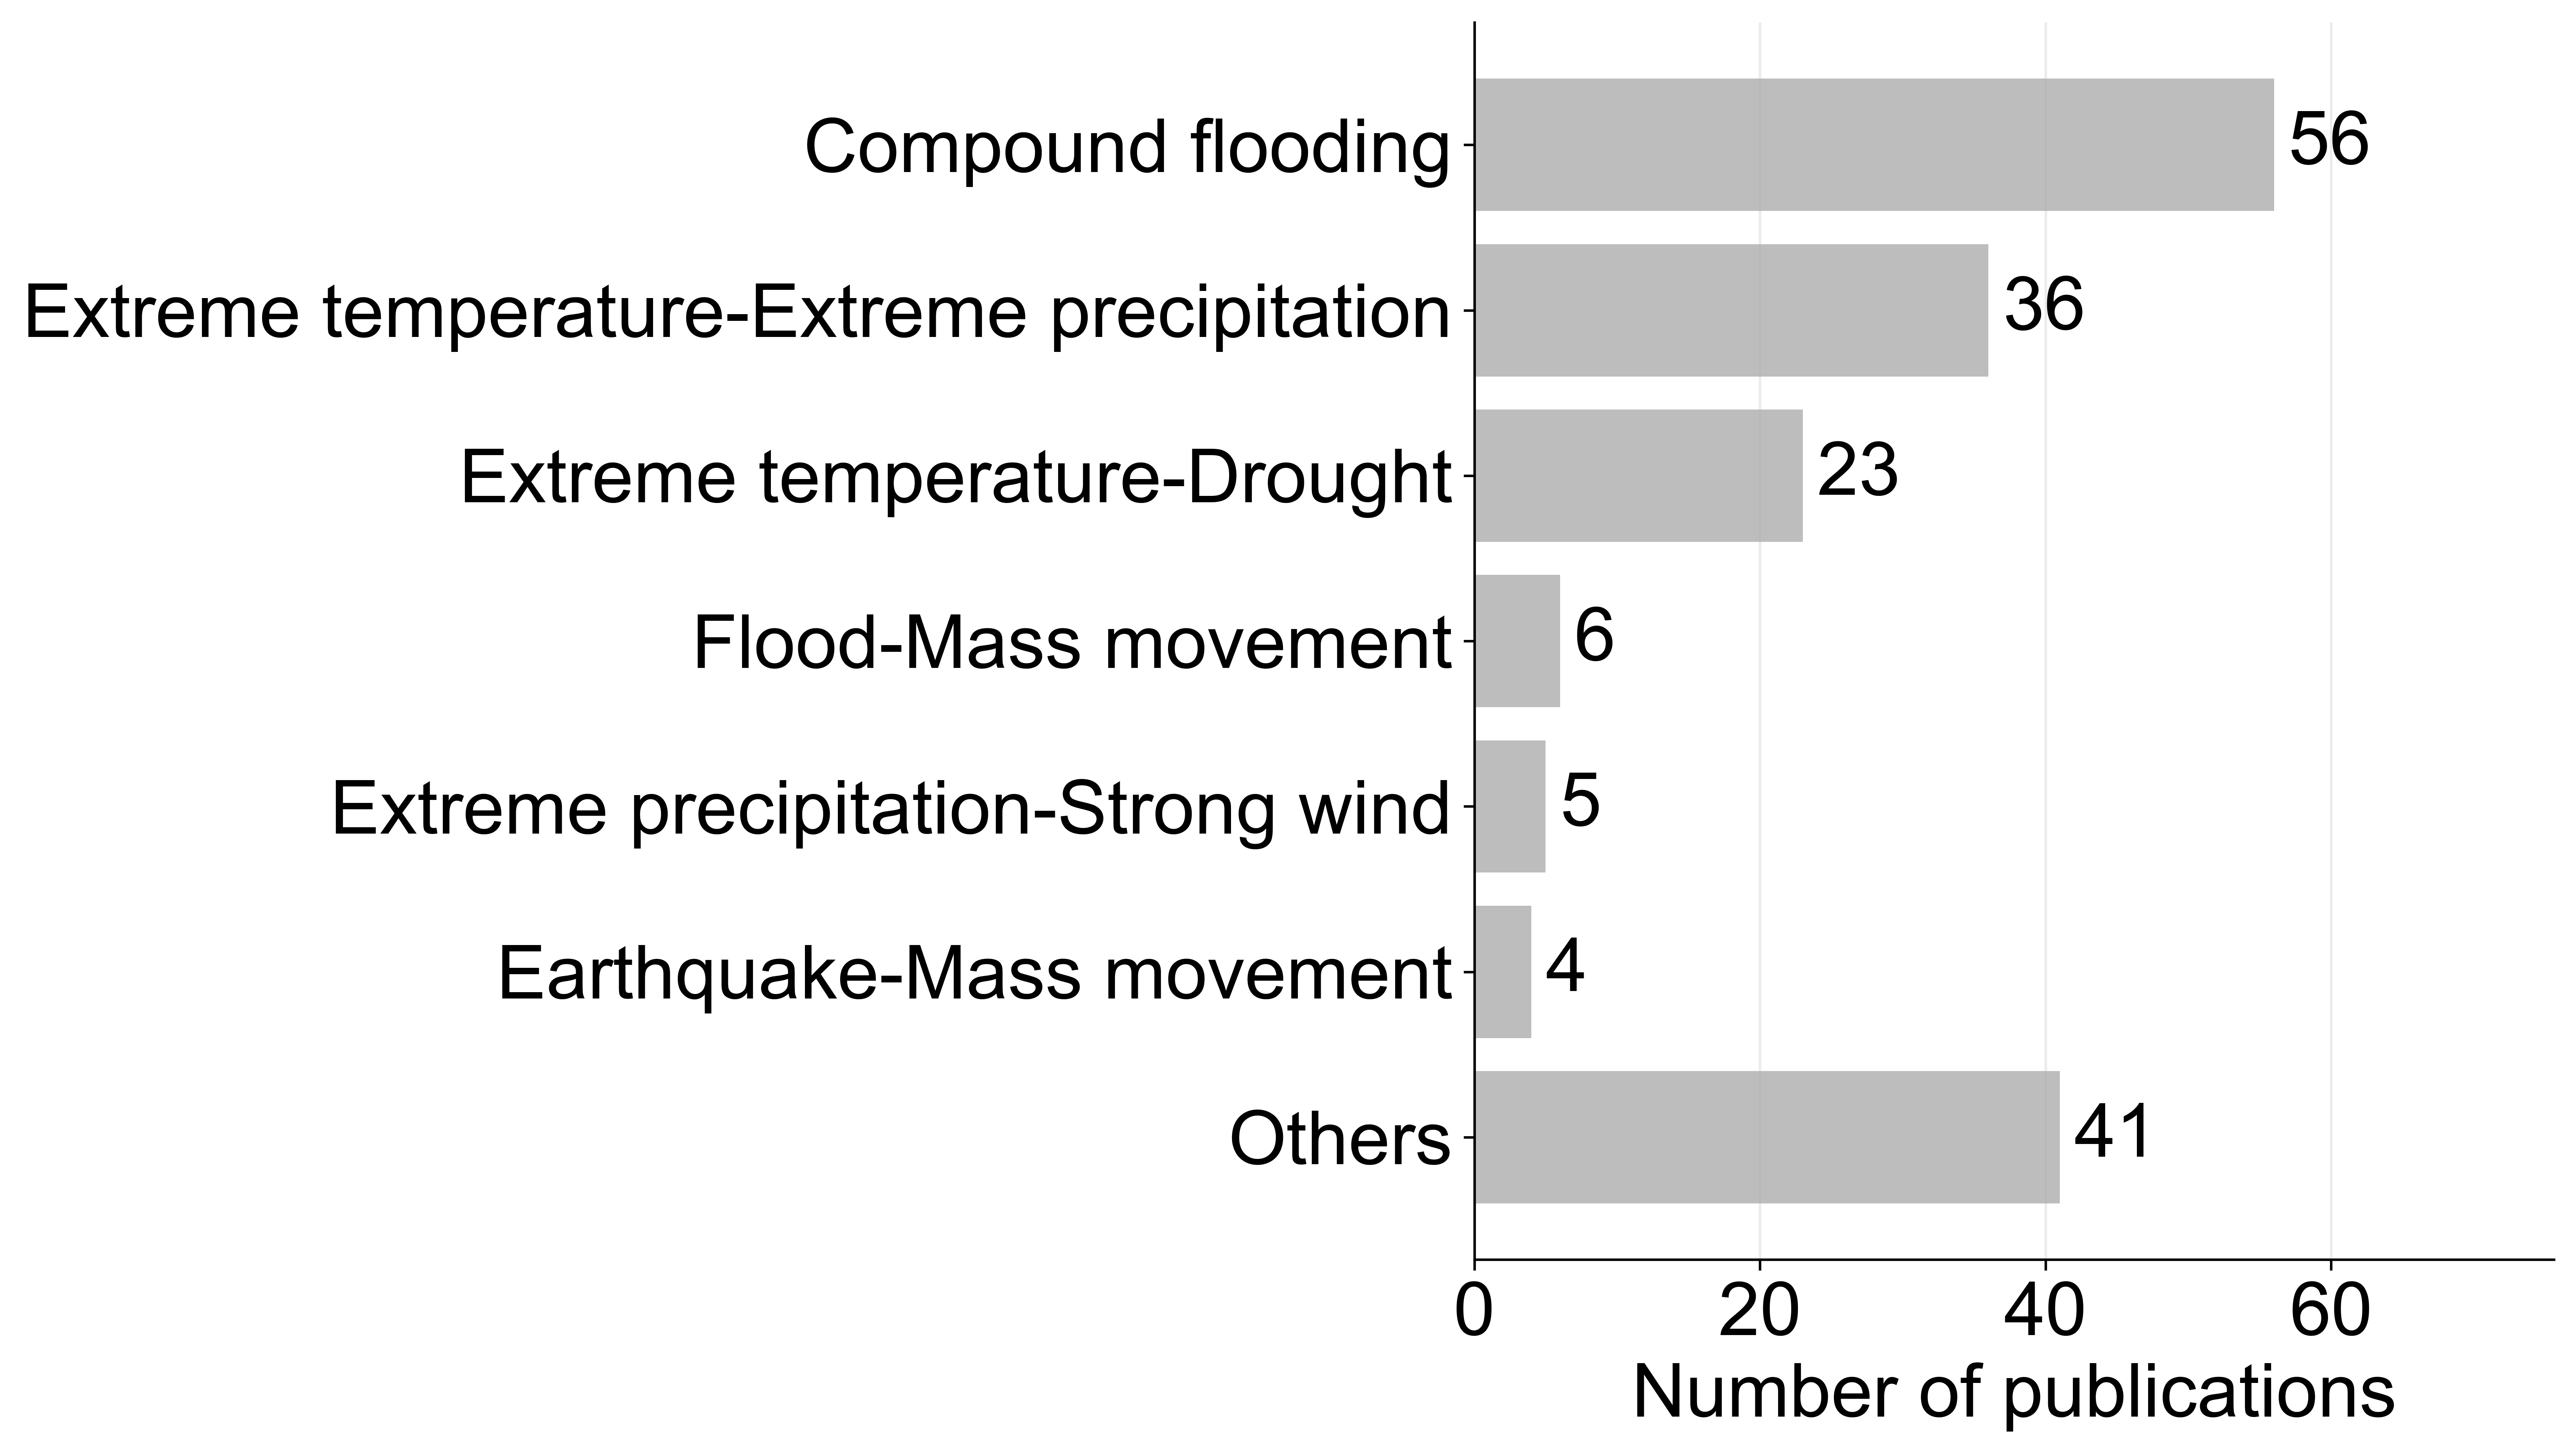

In [27]:
fig, ax = plot_compound_hazard_types(hazard_type_sum_clean)

if EXPORT_OUTPUTS and fig is not None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "compound_hazard_type_frequency.png", dpi=600, bbox_inches="tight", facecolor="white")

plt.show()


## 8. Method Co-Occurrence Network

Build an undirected weighted network where nodes are methods and edges indicate methods used together in the same publication.


In [15]:
method_counts = method_count_table(literature_df)
method_counts.head(20)


,Method,Frequency
0,Multivariate dependence modeling,108
1,Hydrodynamic model,27
2,Hydrological model,12
3,Atmospheric model,12
4,Hydraulic model,9
5,Landslide model,7
6,Debris flow model,7
7,Machine learning,5
8,Event coincidence analysis,5
9,Hydrologic model,3


In [16]:
method_edges = method_pair_table(literature_df)
method_graph = build_method_graph(method_edges)

print(f"Method nodes: {method_graph.number_of_nodes():,}")
print(f"Method edges: {method_graph.number_of_edges():,}")
method_edges.head(20)


Method nodes: 19
Method edges: 42


,Source,Target,Weight
0,Hydrodynamic model,Multivariate dependence modeling,7
1,Hydrodynamic model,Landslide model,3
2,Atmospheric model,Hydrodynamic model,3
3,Hydraulic model,Hydrological model,3
4,Hydrodynamic model,Hydrological model,3
5,Hydrological model,Multivariate dependence modeling,3
6,Hydrological model,Landslide model,2
7,Atmospheric model,Hydrological model,2
8,Earthquake model,Hydraulic model,2
9,Hydrological model,Wave model,2


## 9. Sankey Flow Diagrams

Visualize the relationship between spatial scale, method category, and specific methods.


In [65]:
scale_category_sankey = make_scale_category_sankey(literature_df)
scale_category_sankey.show()

if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    try:
        scale_category_sankey.write_image(OUTPUT_DIR / "scale_to_method_category_sankey_with_label.png", width=1200, height=900, scale=3)
    except Exception as exc:
        print(f"Could not export Sankey image. Install kaleido to enable Plotly image export: {exc}")


In [18]:
# scale_category_method_sankey = make_scale_category_method_sankey(literature_df)
# scale_category_method_sankey.show()

# if EXPORT_OUTPUTS:
#     OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#     try:
#         scale_category_method_sankey.write_image(OUTPUT_DIR / "scale_category_method_sankey.png", width=1400, height=1000, scale=3)
#     except Exception as exc:
#         print(f"Could not export Sankey image. Install kaleido to enable Plotly image export: {exc}")


## 10. Optional Exports

Set `EXPORT_OUTPUTS = True` in the setup cell to write cleaned tables and figure files to `OUTPUT_DIR`.


In [19]:
if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # literature_df.to_csv(OUTPUT_DIR / "literature_records_clean.csv", index=False)
    yearly_counts.to_csv(OUTPUT_DIR / "publication_counts_by_year.csv", index=False)
    yearly_category_counts.to_csv(OUTPUT_DIR / "publication_counts_by_year_and_method_category.csv")
    scale_counts.to_csv(OUTPUT_DIR / "publication_counts_by_scale.csv", index=False)
    scale_category_share.to_csv(OUTPUT_DIR / "method_category_share_by_scale.csv")
    # hazard_type_sum_clean.to_csv(OUTPUT_DIR / "compound_hazard_type_frequency.csv", index=False)
    # method_counts.to_csv(OUTPUT_DIR / "method_frequency.csv", index=False)
    # method_edges.to_csv(OUTPUT_DIR / "method_cooccurrence_edges.csv", index=False)
    # method_adjacency.to_csv(OUTPUT_DIR / "method_cooccurrence_adjacency.csv")
    print(f"Exported trend analysis tables to {OUTPUT_DIR}")
else:
    print("Exports are disabled. Set EXPORT_OUTPUTS = True to write tables and figures.")


Exported trend analysis tables to C:\Users\hai\OneDrive - Georgia Institute of Technology\06_Research_PRJ_2025_Review\code\compound-hazard-review\output\trend_analysis
